# 🔍 Adım 2 — Derin Veri Keşfi (EDA)
Burada şu 5 soruyu cevaplayacağız:
1. İki sınıf görsel olarak ayrışıyor mu? (PCA)
2. Hangi özellikler sınıfı en çok ayırt ediyor? (İstatistiksel testler)
3. Özellikler birbiriyle ne kadar iç içe? (Korelasyon)
4. Hangi özellikler neredeyse sabit? (Varyans)
5. Aykırı değerler ne durumda? (IQR)
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

# Veriyi yükle ve birleştir
normal = pd.read_csv('normal_radiomics.csv')
papil  = pd.read_csv('papilodem_radiomics.csv')
normal['label'] = 0
papil['label']  = 1
df = pd.concat([normal, papil], ignore_index=True)

feature_cols = [c for c in df.columns if c.startswith('Feature_')]
X = df[feature_cols].values
y = df['label'].values

print(f'Veri hazır: {df.shape[0]} satır, {len(feature_cols)} özellik')

Veri hazır: 966 satır, 746 özellik


/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel_47663/600655937.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normal['label'] = 0
/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel_47663/600655937.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  papil['label']  = 1


---
## SORU 1: İki sınıf görsel olarak ayrışıyor mu?

**PCA (Principal Component Analysis)** nedir?  
746 boyutlu veriyi 2 boyuta indirgemek. Bunu yaparken en çok bilgi taşıyan yönleri bulur.  
Eğer 2D'de bile kümeler görünüyorsa → model kolay öğrenecek demektir.

In [2]:
# Önce ölçekleme (PCA için zorunlu)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# PCA — 2 bileşen
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var1, var2 = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0: 'steelblue', 1: 'salmon'}
labels = {0: 'Normal', 1: 'Papilödem'}
for cls in [0, 1]:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], label=labels[cls],
               alpha=0.5, s=20, edgecolors='none')
ax.set_xlabel(f'PC1 ({var1:.1f}% varyans)')
ax.set_ylabel(f'PC2 ({var2:.1f}% varyans)')
ax.set_title('PCA — 746 özellik → 2 boyut')
ax.legend()
plt.tight_layout()
plt.savefig('fig_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Kaç bileşen %80 varyansı açıklıyor?
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n80 = np.argmax(cumvar >= 0.80) + 1
n95 = np.argmax(cumvar >= 0.95) + 1
print(f'\nPC1+PC2 toplam açıklanan varyans: {var1+var2:.1f}%')
print(f'%80 varyans için gereken bileşen sayısı: {n80}')
print(f'%95 varyans için gereken bileşen sayısı: {n95}')

ValueError: Input X contains infinity or a value too large for dtype('float64').

---
## SORU 2: Hangi özellikler sınıfı en çok ayırt ediyor?

Her özellik için **Mann-Whitney U testi** uyguluyoruz.  
Bu test: "Bu özelliğin değerleri iki sınıfta gerçekten farklı mı, yoksa tesadüf mü?" sorusunu cevaplar.  
Sadece p-value yetmez — **etki büyüklüğü (effect size)** de önemli. Küçük p ≠ büyük etki.

> **Rank-biserial correlation (r):** 0 = hiç etki yok, 1 = tam ayırt edici

In [3]:
print('İstatistiksel testler hesaplanıyor... (biraz sürebilir)')

results = []
x_normal = df[df.label == 0][feature_cols].values
x_papil  = df[df.label == 1][feature_cols].values

for i, feat in enumerate(feature_cols):
    u_stat, p_val = stats.mannwhitneyu(x_normal[:, i], x_papil[:, i], alternative='two-sided')
    # Rank-biserial correlation (etki büyüklüğü)
    n1, n2 = len(x_normal), len(x_papil)
    r = 1 - (2 * u_stat) / (n1 * n2)
    results.append({'feature': feat, 'p_value': p_val, 'effect_size': abs(r)})

result_df = pd.DataFrame(results).sort_values('effect_size', ascending=False)

# Bonferroni düzeltmesi (746 test yaptık, eşiği düşürmeliyiz)
alpha_bonferroni = 0.05 / len(feature_cols)
anlamli = result_df[result_df.p_value < alpha_bonferroni]

print(f'Toplam özellik          : {len(feature_cols)}')
print(f'Bonferroni eşiği        : {alpha_bonferroni:.2e}')
print(f'İstatistiksel anlamlı   : {len(anlamli)} özellik')
print(f'\nEn ayırt edici TOP 10:')
display(result_df.head(10)[['feature', 'p_value', 'effect_size']].round(4))

İstatistiksel testler hesaplanıyor... (biraz sürebilir)
Toplam özellik          : 746
Bonferroni eşiği        : 6.70e-05
İstatistiksel anlamlı   : 435 özellik

En ayırt edici TOP 10:


,feature,p_value,effect_size
223,Feature_0224,0.0,0.8321
453,Feature_0454,0.0,0.8285
408,Feature_0409,0.0,0.8176
407,Feature_0408,0.0,0.8097
82,Feature_0083,0.0,0.8097
469,Feature_0470,0.0,0.8061
101,Feature_0102,0.0,0.8039
434,Feature_0435,0.0,0.8036
315,Feature_0316,0.0,0.8021
85,Feature_0086,0.0,0.7999


/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel_47663/1520497737.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_n, data_p], labels=['Normal', 'Papilödem'],
/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel_47663/1520497737.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_n, data_p], labels=['Normal', 'Papilödem'],
/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel_47663/1520497737.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_n, data_p], labels=['Normal', 'Papilödem'],
/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel

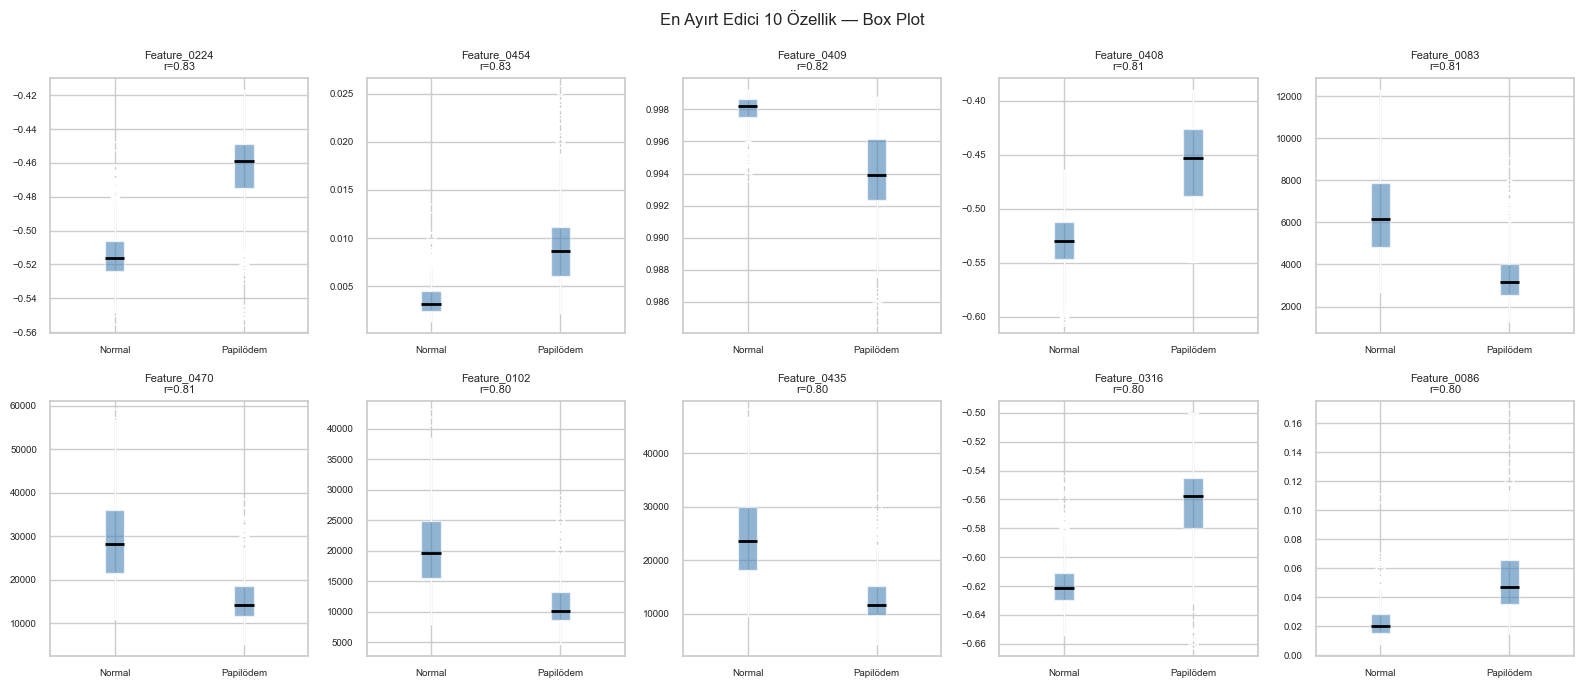

In [4]:
# En ayırt edici 10 özellik için box plot
top10 = result_df.head(10)['feature'].tolist()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, feat in zip(axes.flatten(), top10):
    data_n = df[df.label == 0][feat]
    data_p = df[df.label == 1][feat]
    ax.boxplot([data_n, data_p], labels=['Normal', 'Papilödem'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    r_val = result_df[result_df.feature == feat]['effect_size'].values[0]
    ax.set_title(f'{feat}\nr={r_val:.2f}', fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle('En Ayırt Edici 10 Özellik — Box Plot', fontsize=12)
plt.tight_layout()
plt.savefig('fig_top10_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SORU 3: Özellikler birbiriyle ne kadar iç içe? (Korelasyon)

746 özellik birbirinden bağımsız değil. Çoğu muhtemelen birbirinin kopyası gibi.  
Yüksek korelasyonlu özellikler modele gereksiz gürültü katar → **özellik eleme** bu yüzden kritik.

In [5]:
print('Korelasyon matrisi hesaplanıyor...')
corr_matrix = df[feature_cols].corr().abs()

# Üst üçgen (kendisiyle korelasyonu çıkar)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Yüksek korelasyonlu çiftler
thresholds = [0.95, 0.90, 0.80, 0.70]
print('Korelasyon eşiğine göre özellik çifti sayısı:')
for thr in thresholds:
    n = (upper > thr).sum().sum()
    print(f'  |r| > {thr}: {n} çift')

# |r| > 0.95 durumunda elenmesi gereken özellik sayısı
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'\n|r| > 0.95 eşiğiyle elenecek özellik sayısı: {len(to_drop)}')
print(f'Kalan özellik tahmini: {len(feature_cols) - len(to_drop)}')

Korelasyon matrisi hesaplanıyor...
Korelasyon eşiğine göre özellik çifti sayısı:
  |r| > 0.95: 3842 çift
  |r| > 0.9: 8617 çift
  |r| > 0.8: 21861 çift
  |r| > 0.7: 40384 çift

|r| > 0.95 eşiğiyle elenecek özellik sayısı: 504
Kalan özellik tahmini: 242


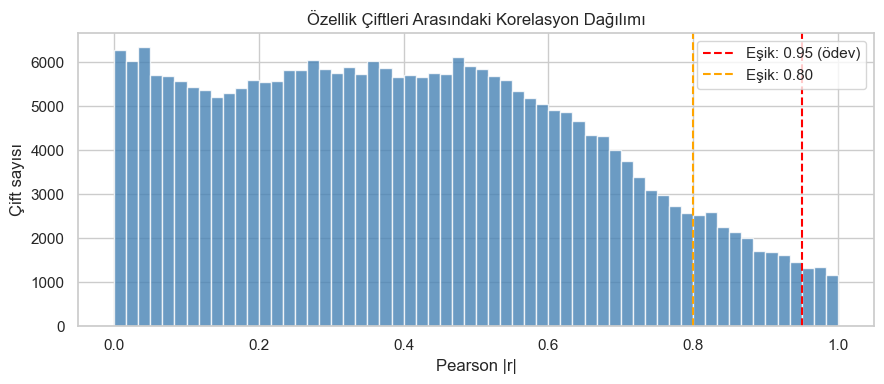

In [6]:
# Korelasyon dağılımı histogramı
corr_vals = upper.values[upper.values > 0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(corr_vals, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.95, color='red',    linestyle='--', label='Eşik: 0.95 (ödev)')
ax.axvline(0.80, color='orange', linestyle='--', label='Eşik: 0.80')
ax.set_xlabel('Pearson |r|')
ax.set_ylabel('Çift sayısı')
ax.set_title('Özellik Çiftleri Arasındaki Korelasyon Dağılımı')
ax.legend()
plt.tight_layout()
plt.savefig('fig_korelasyon_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SORU 4: Hangi özellikler neredeyse sabit? (Varyans)

Eğer bir özelliğin değeri tüm hastalarda aynıysa, o özellik **hiçbir bilgi taşımıyor** demektir.  
Makine öğrenmesi modelleri bu tür özelliklerden bir şey öğrenemez, aksine gürültü yaratır.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


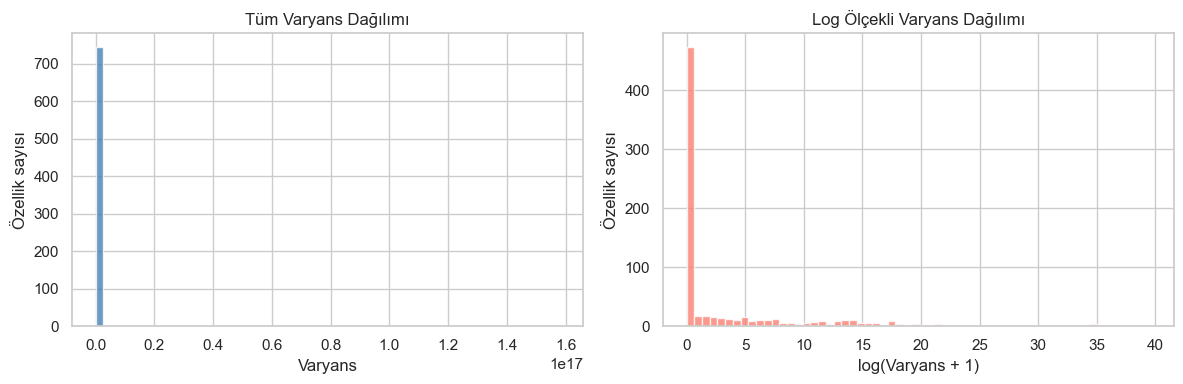

Varyans ≤ 0: 7 özellik
Varyans ≤ 0.01: 327 özellik
Varyans ≤ 0.1: 415 özellik


In [7]:
variances = df[feature_cols].var()

# Varyans dağılımı
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(variances, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Varyans')
axes[0].set_ylabel('Özellik sayısı')
axes[0].set_title('Tüm Varyans Dağılımı')

# Log ölçeğinde daha net görünür
axes[1].hist(np.log1p(variances), bins=60, color='salmon', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('log(Varyans + 1)')
axes[1].set_ylabel('Özellik sayısı')
axes[1].set_title('Log Ölçekli Varyans Dağılımı')

plt.tight_layout()
plt.savefig('fig_varyans.png', dpi=150, bbox_inches='tight')
plt.show()

# Düşük varyanslı özellikler
for thr in [0, 0.01, 0.1]:
    n = (variances <= thr).sum()
    print(f'Varyans ≤ {thr}: {n} özellik')

---
## SORU 5: Aykırı değerler ne durumda?

**IQR yöntemi:** Q1 - 1.5×IQR altı veya Q3 + 1.5×IQR üstü olan değerler aykırı sayılır.  
Aykırı değer **mutlaka silinmez** — ama nerede olduğunu bilmek gerekir.

En az 1 aykırı değer içeren satır: 871 / 966 (90.2%)

En fazla aykırı değer içeren 10 özellik:


,aykırı_değer_sayısı
Feature_0568,294
Feature_0724,266
Feature_0743,266
Feature_0742,266
Feature_0706,266
Feature_0746,265
Feature_0672,265
Feature_0673,265
Feature_0693,265
Feature_0707,265


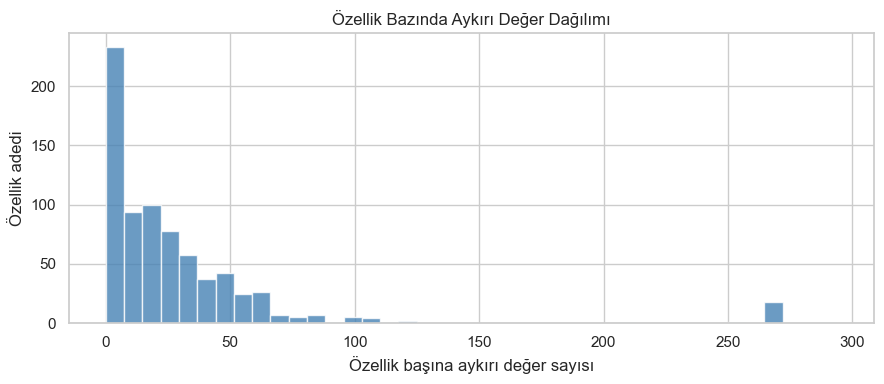

In [8]:
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[feature_cols] < (Q1 - 1.5 * IQR)) |
                (df[feature_cols] > (Q3 + 1.5 * IQR)))

# Satır bazında: kaç satırda en az 1 aykırı değer var?
satir_bazli = outlier_mask.any(axis=1).sum()
# Özellik bazında: en fazla aykırı değer hangi özelliklerde?
ozellik_bazli = outlier_mask.sum(axis=0).sort_values(ascending=False)

print(f'En az 1 aykırı değer içeren satır: {satir_bazli} / {len(df)} ({satir_bazli/len(df)*100:.1f}%)')
print(f'\nEn fazla aykırı değer içeren 10 özellik:')
display(ozellik_bazli.head(10).to_frame('aykırı_değer_sayısı'))

# Görsel
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(outlier_mask.sum(axis=0), bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Özellik başına aykırı değer sayısı')
ax.set_ylabel('Özellik adedi')
ax.set_title('Özellik Bazında Aykırı Değer Dağılımı')
plt.tight_layout()
plt.savefig('fig_aykiri_deger.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA Genel Özet

In [9]:
print('=' * 50)
print('EDA ÖZET TABLOSU')
print('=' * 50)
print(f'Toplam özellik               : {len(feature_cols)}')
print(f'İstatistiksel anlamlı özellik: {len(anlamli)} (Bonferroni düzeltmeli)')
print(f'Yüksek korelasyonlu (>0.95)  : {len(to_drop)} özellik elenecek')
print(f'Düşük varyanslı (≤0.01)      : {(variances <= 0.01).sum()} özellik elenecek')
print(f'Aykırı değer oranı           : satırların %{satir_bazli/len(df)*100:.1f}inde var')
print(f'PC1+PC2 açıklanan varyans    : {var1+var2:.1f}%')
print('=' * 50)
print('\nSıradaki adım → Adım 3: Veri ön işleme pipeline')

EDA ÖZET TABLOSU
Toplam özellik               : 746
İstatistiksel anlamlı özellik: 435 (Bonferroni düzeltmeli)
Yüksek korelasyonlu (>0.95)  : 504 özellik elenecek
Düşük varyanslı (≤0.01)      : 327 özellik elenecek
Aykırı değer oranı           : satırların %90.2inde var


NameError: name 'var1' is not defined